In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/DAC_204_dataset/ISBI2016_ISIC_Part1_Training_GroundTruth.zip"
extract_path = "/content/unzip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

zip_path2 = "/content/drive/MyDrive/DAC_204_dataset/ISBI2016_ISIC_Part1_Training_Data.zip"
extract_path2 = "/content/unzip"

with zipfile.ZipFile(zip_path2, 'r') as zip_ref2:
    zip_ref2.extractall(extract_path2)

In [3]:
import os
import shutil
from tqdm import tqdm
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Google collab Paths
RAW_IMG_DIR = "/content/unzip/ISBI2016_ISIC_Part1_Training_Data"
RAW_MASK_DIR = "/content/unzip/ISBI2016_ISIC_Part1_Training_GroundTruth"

NEW_IMG_DIR = "/content/dataset/images"
NEW_MASK_DIR = "/content/dataset/masks"

# Local Paths

# RAW_IMG_DIR = "../Raw_Dataset/ISBI2016_ISIC_Part1_Training_Data"
# RAW_MASK_DIR = "../Raw_Dataset/ISBI2016_ISIC_Part1_Training_GroundTruth"

# NEW_IMG_DIR = "../dataset/images"
# NEW_MASK_DIR = "../dataset/masks"

os.makedirs(NEW_IMG_DIR, exist_ok=True)
os.makedirs(NEW_MASK_DIR, exist_ok=True)

# Process files
missing_masks = []

for img_name in tqdm(os.listdir(RAW_IMG_DIR)):
    if img_name.endswith(".jpg"):

        img_path = os.path.join(RAW_IMG_DIR, img_name)

        mask_name = img_name.replace(".jpg", "_Segmentation.png")
        mask_path = os.path.join(RAW_MASK_DIR, mask_name)

        new_mask_name = img_name.replace(".jpg", ".png")
        shutil.copy(img_path, os.path.join(NEW_IMG_DIR, img_name))

        if os.path.exists(mask_path):
            shutil.copy(mask_path, os.path.join(NEW_MASK_DIR, new_mask_name))
        else:
            missing_masks.append(img_name)

print(f"Total images processed: {len(os.listdir(NEW_IMG_DIR))}")
print(f"Missing masks: {len(missing_masks)}")

if missing_masks:
    print("Example missing:", missing_masks[:5])

100%|██████████| 900/900 [00:03<00:00, 259.16it/s]

Total images processed: 900
Missing masks: 0


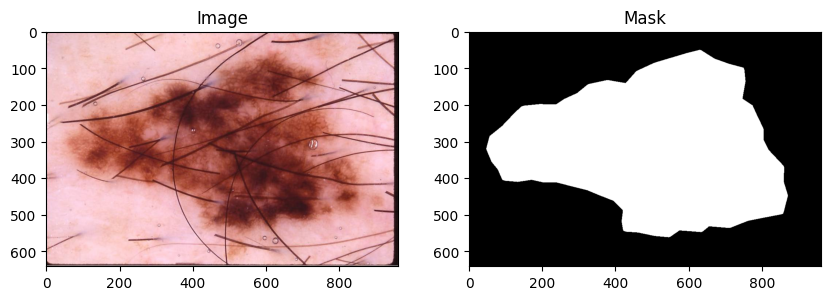

In [5]:
images = sorted(os.listdir("dataset/images"))
masks  = sorted(os.listdir("dataset/masks"))

# Choosing a Random image from the DataSet
img_name = random.choice(images)
img_path = os.path.join("dataset/images", img_name)
mask_path = os.path.join("dataset/masks", img_name.replace(".jpg", ".png"))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.show()

In [6]:
vals, frequency = np.unique(mask, return_counts=True)
print(f"Unique Mask Values   :{vals}")
print(f"Count of Mask Values :{frequency}\n")

print(f"Shape of the IMAGE  :{img.shape}")

# # DATASET FETCH AND CLEAN COMPLETE///

Unique Mask Values   :[  0 255]
Count of Mask Values :[353614 263028]

Shape of the IMAGE  :(641, 962, 3)


In [7]:
# Custom Dataset Class

class ISICDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))
        image = image / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (256, 256))
        mask = (mask > 127).astype(np.float32)

        image = np.transpose(image, (2, 0, 1))  # HWC → CHW
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [8]:
from torch.utils.data import random_split

full_dataset = ISICDataset("dataset/images", "dataset/masks")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

Train size: 720
Val size: 180


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# Shuffle set to true -> generalization
# 8 (image, mask) will be fed at a time. Shuffle = True for generalization. Batching is for stable gradient and speed
# Batch Size of 8 (8 at a time), Stable Gradient and Speed...

##**U-Net Architecture**

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(3, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))

        b = self.bottleneck(self.p3(d3))

        u3 = self.u3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.c3(u3)

        u2 = self.u2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.c2(u2)

        u1 = self.u1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.c1(u1)

        return self.out(u1)

**Defining Dice loss, Dice score, and IoU score**

In [11]:
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def dice_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)


**Initializing model, optimizer, loss function, and scheduler**

In [12]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()

**Training loop with validation and metrics (IoU and Dice)**

In [13]:
epochs = 20
best_dice = 0
best_iou = 0

for epoch in range(epochs):

    # Train
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = bce(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = bce(preds, masks)
            val_loss += loss.item()

            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()

    avg_dice = total_dice / len(val_loader)
    avg_iou = total_iou / len(val_loader)

    # Save best model
    if avg_dice > best_dice:
        best_dice = avg_dice
        best_iou = avg_iou
        torch.save(model.state_dict(), "best_model.pth")

    print(f"""
Epoch {epoch+1}/{epochs}
Train Loss: {train_loss/len(train_loader):.4f}
Val Loss  : {val_loss/len(val_loader):.4f}
Dice Score: {avg_dice:.4f}
IoU Score : {avg_iou:.4f}
""")

# FINAL BEST SCORES
print("\nBest Model Performance")
print(f"Best Dice Score: {best_dice:.4f}")
print(f"Best IoU Score : {best_iou:.4f}")


Epoch 1/20
Train Loss: 0.5166
Val Loss  : 0.4608
Dice Score: 0.6550
IoU Score : 0.4956


Epoch 2/20
Train Loss: 0.4419
Val Loss  : 0.4781
Dice Score: 0.4999
IoU Score : 0.3420


Epoch 3/20
Train Loss: 0.4235
Val Loss  : 0.4032
Dice Score: 0.6280
IoU Score : 0.4668


Epoch 4/20
Train Loss: 0.4122
Val Loss  : 0.4794
Dice Score: 0.0299
IoU Score : 0.0155


Epoch 5/20
Train Loss: 0.4395
Val Loss  : 0.3755
Dice Score: 0.7453
IoU Score : 0.6028


Epoch 6/20
Train Loss: 0.4593
Val Loss  : 0.4225
Dice Score: 0.6775
IoU Score : 0.5230


Epoch 7/20
Train Loss: 0.4128
Val Loss  : 0.4166
Dice Score: 0.6515
IoU Score : 0.4952


Epoch 8/20
Train Loss: 0.4122
Val Loss  : 0.4137
Dice Score: 0.6802
IoU Score : 0.5262


Epoch 9/20
Train Loss: 0.4085
Val Loss  : 0.4094
Dice Score: 0.6585
IoU Score : 0.5018


Epoch 10/20
Train Loss: 0.3980
Val Loss  : 0.4090
Dice Score: 0.6467
IoU Score : 0.4894


Epoch 11/20
Train Loss: 0.4020
Val Loss  : 0.4004
Dice Score: 0.6258
IoU Score : 0.4656


Epoch 12/20
Train 

In [14]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

UNet(
  (d1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p3): MaxPool2d(

**Visualizing Predictions vs Ground Truth**

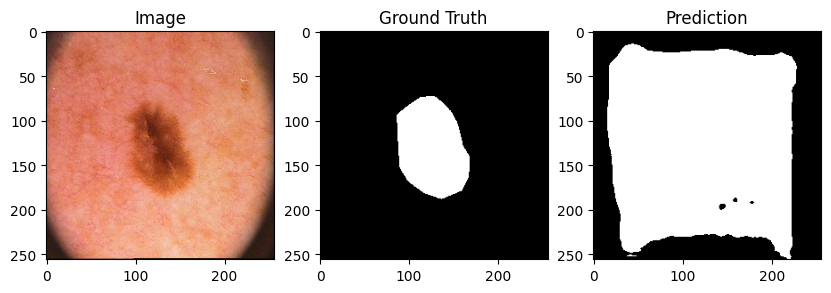

In [15]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)
    preds = torch.sigmoid(preds)

preds = preds.cpu().numpy()
preds = (preds > 0.5).astype(np.float32)
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(images[0].cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[0].squeeze(), cmap='gray')

plt.show()